# MLOps Assignment 1: Step 1 - Data Acquisition & Exploratory Data Analysis (EDA)
**Dataset:** Heart Disease UCI Dataset[cite: 1, 2]
**Objective:** Obtain the dataset, perform missing value analysis, and create professional visualizations including histograms, correlation heatmaps, and class distribution plots[cite: 1, 2].

In [4]:
# Import required libraries for data processing and visualization
!pip install seaborn pandas numpy matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Data Acquisition
We are fetching the Heart Disease dataset directly from the UCI Machine Learning Repository[cite: 2]. The dataset contains 14 attributes, with the `target` column indicating the presence or absence of heart disease[cite: 2].

In [5]:
# Define column names based on UCI documentation
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", 
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

# Download script: Load dataset directly into a Pandas DataFrame
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, names=columns, na_values="?")

# Display the first few rows
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Missing Value Analysis & Data Cleaning
We need to identify and handle missing values before proceeding with deeper analysis[cite: 1].

In [6]:
# Check for missing values
print("Missing values in each column:\n", df.isnull().sum())

# Handle missing values: We will impute the missing values with the median of their respective columns
df = df.fillna(df.median())
print("\nMissing values after imputation:\n", df.isnull().sum())

# The target variable contains values from 0 to 4. 
# We need to convert this into a binary classification problem (0 = absence, 1+ = presence)[cite: 2].
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

Missing values in each column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Missing values after imputation:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

### 3.1 Class Distribution Plot
First, let's check the balance of our target classes to see if we have a class imbalance issue[cite: 1].

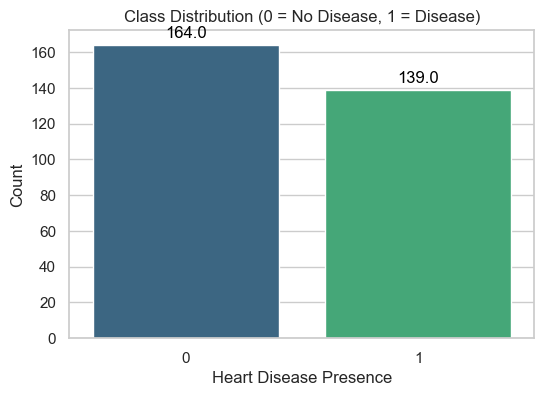

In [7]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=df, palette='viridis')
plt.title('Class Distribution (0 = No Disease, 1 = Disease)')
plt.xlabel('Heart Disease Presence')
plt.ylabel('Count')

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')
plt.show()

### 3.2 Histograms for Numerical Features
Let's analyze the distributions of continuous features like age, cholesterol, and max heart rate[cite: 1].

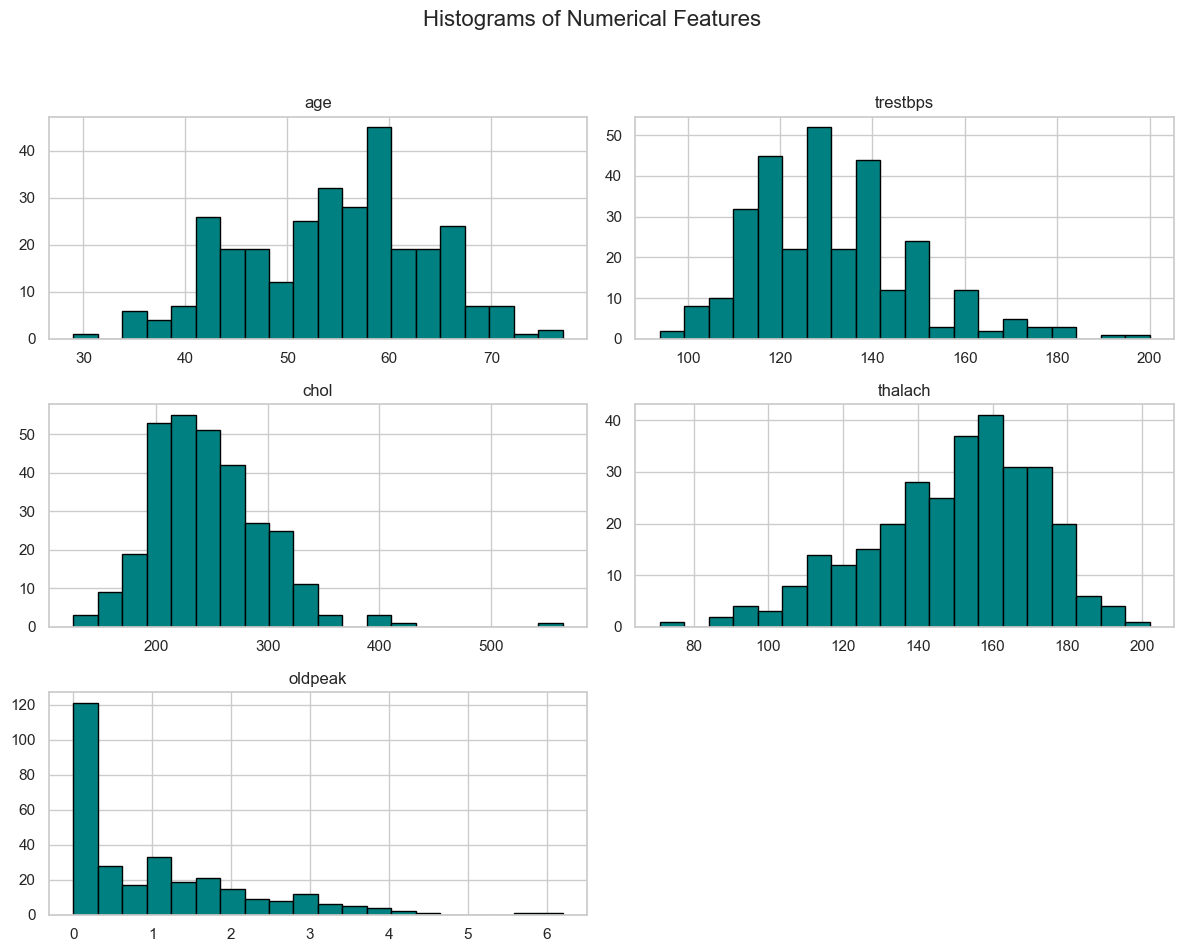

In [8]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

df[numeric_features].hist(figsize=(12, 10), bins=20, color='teal', edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 3.3 Feature Relationship Analysis
Let's explore how age and maximum heart rate relate to the presence of heart disease[cite: 1].

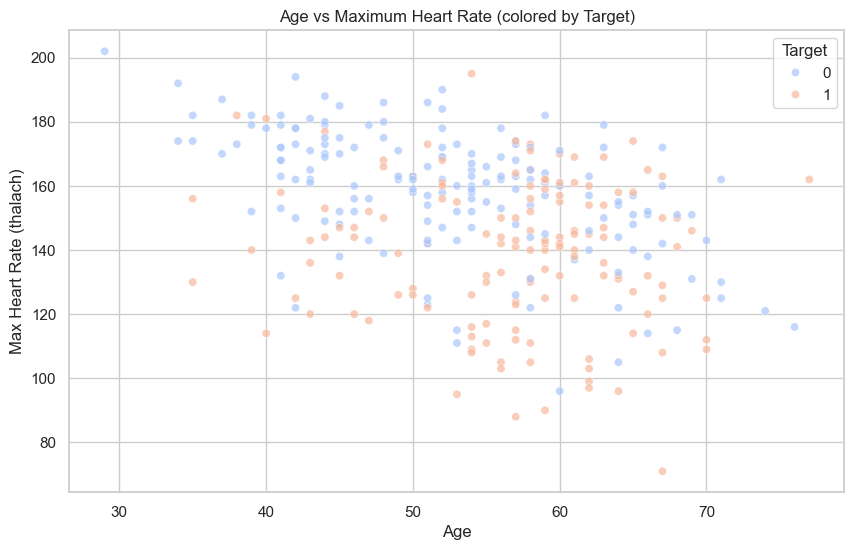

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='thalach', hue='target', data=df, palette='coolwarm', alpha=0.7)
plt.title('Age vs Maximum Heart Rate (colored by Target)')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate (thalach)')
plt.legend(title='Target')
plt.show()

### 3.4 Correlation Heatmap
A correlation heatmap helps us identify multicollinearity and understand which features are most linearly related to our target variable[cite: 1].

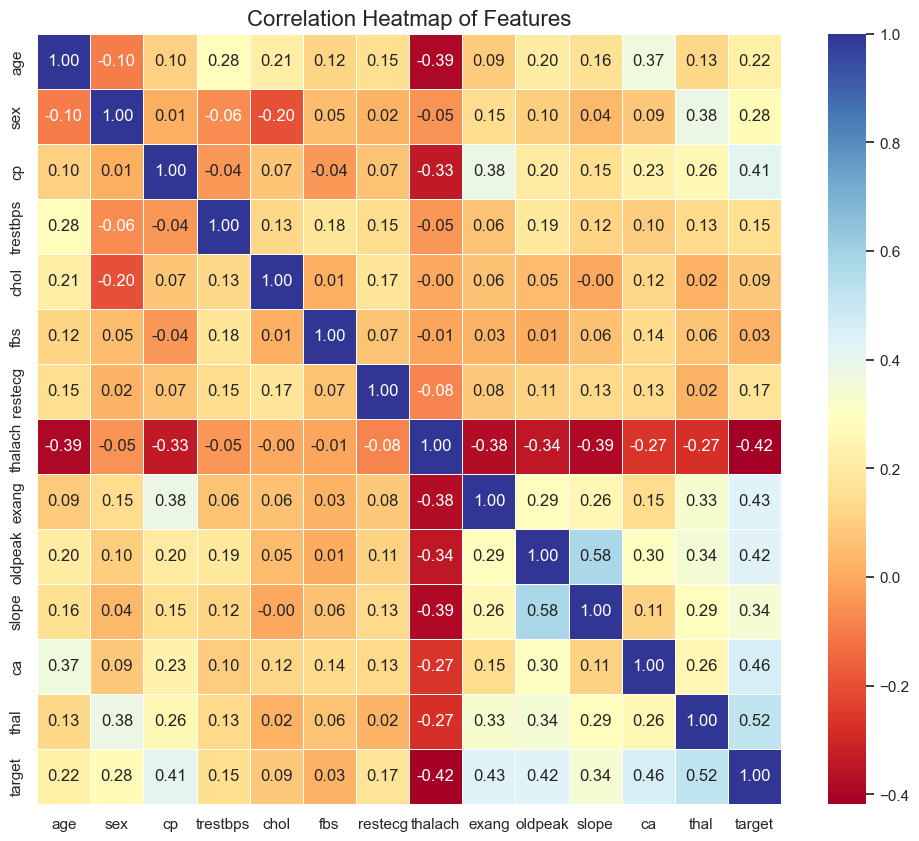

In [10]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()

# Create a heatmap using seaborn
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Features', fontsize=16)
plt.show()